# Modelo de probabilidad de recompra — Online Retail II

**Máster en Machine Learning — Ejercicio práctico**

**Objetivo de negocio:** identificar clientes con alta vs. baja probabilidad de **volver a comprar**, para dirigir acciones de *fidelización* (alta prob.) y *retención* (baja prob.).

**Planteamiento técnico:** el dataset son transacciones, no clientes. No existe una etiqueta "recompra", así que la **construimos** con un corte temporal:
1. Elegimos una **fecha de corte** (`2011-06-09`).
2. Con los datos **anteriores** al corte → variables por cliente (RFM: recencia, frecuencia, gasto…).
3. Con los datos **posteriores** al corte → etiqueta `recompra` (1/0).
4. Entrenamos modelos y medimos el **AUC**.

**Índice**
1. Carga y EDA
2. Limpieza y exclusiones
3. Variable objetivo y features (RFM)
4. Modelos
5. Optimización y resultados
6. Aplicación de negocio

## 1. Carga y EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 20)
plt.style.use('ggplot'); sns.set_palette('husl')
RANDOM_STATE = 42

Cargamos las **2 hojas** del Excel (años 2009-2010 y 2010-2011) y las concatenamos.

In [2]:
DATA_PATH = 'online_retail_II.xlsx'
xl = pd.ExcelFile(DATA_PATH)
df = pd.concat([pd.read_excel(DATA_PATH, sheet_name=s) for s in xl.sheet_names],
               ignore_index=True)
df.columns = [c.strip() for c in df.columns]
print(f'Filas: {len(df):,} | Columnas: {len(df.columns)}')
df.head()

Filas: 1,067,371 | Columnas: 8


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 65.1+ MB


### 1.1 Calidad de datos

In [4]:
n = len(df)
canc = df['Invoice'].astype(str).str.startswith('C')
resumen = {
    'Rango fechas'      : f"{df['InvoiceDate'].min()} -> {df['InvoiceDate'].max()}",
    'Filas'             : n,
    'Clientes unicos'   : df['Customer ID'].nunique(),
    'Facturas unicas'   : df['Invoice'].nunique(),
    'Paises'            : df['Country'].nunique(),
    'Nulos Description' : int(df['Description'].isna().sum()),
    'Nulos Customer ID' : f"{df['Customer ID'].isna().sum():,} ({df['Customer ID'].isna().mean()*100:.1f}%)",
    'Duplicados'        : int(df.duplicated().sum()),
    'Cancelaciones (C)' : f"{canc.sum():,} ({canc.mean()*100:.2f}%)",
    'Quantity <= 0'     : int((df['Quantity']<=0).sum()),
    'Price <= 0'        : int((df['Price']<=0).sum()),
}
for k,v in resumen.items():
    print(f'{k:20s}: {v}')

Rango fechas        : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Filas               : 1067371
Clientes unicos     : 5942
Facturas unicas     : 53628
Paises              : 43
Nulos Description   : 4382
Nulos Customer ID   : 243,007 (22.8%)
Duplicados          : 34335
Cancelaciones (C)   : 19,494 (1.83%)
Quantity <= 0       : 22950
Price <= 0          : 6207


**Lo que vemos:**
- Histórico de **24 meses** (dic-2009 → dic-2011), **5.942 clientes**, **43 países**.
- **22,8 % de filas sin `Customer ID`** → no se pueden asignar a un cliente.
- **1,83 % cancelaciones** (facturas que empiezan por `C`, con `Quantity` negativa).
- ~34k duplicados y ventas con `Quantity`/`Price` ≤ 0.
- **Reino Unido domina** (~92 % de las filas).

### 1.2 Visualizaciones

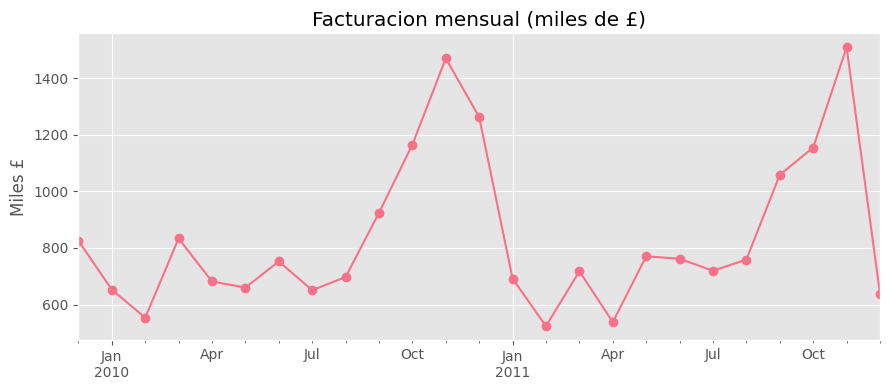

In [5]:
d = df.copy()
d['Revenue'] = d['Quantity'] * d['Price']
validas = (d['Quantity']>0) & (d['Price']>0) & (~d['Invoice'].astype(str).str.startswith('C'))
d_ok = d[validas]

fig, ax = plt.subplots(figsize=(9,4))
(d_ok.set_index('InvoiceDate')['Revenue'].resample('ME').sum()/1000).plot(ax=ax, marker='o')
ax.set_title('Facturacion mensual (miles de £)'); ax.set_ylabel('Miles £'); ax.set_xlabel('')
plt.tight_layout(); plt.show()

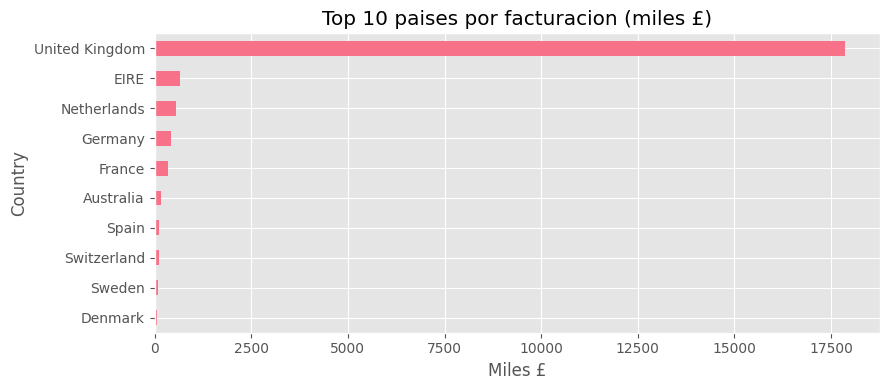

In [6]:
top = (d_ok.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)/1000)
fig, ax = plt.subplots(figsize=(9,4)); top[::-1].plot.barh(ax=ax)
ax.set_title('Top 10 paises por facturacion (miles £)'); ax.set_xlabel('Miles £')
plt.tight_layout(); plt.show()

Clientes con 1 sola compra: 1,623
Clientes con >1 compra   : 4,255  (72.4% recurrentes)


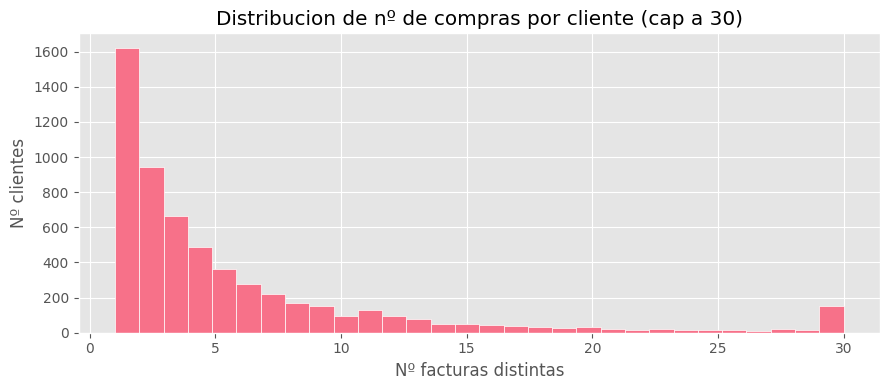

In [7]:
cust = d_ok[d_ok['Customer ID'].notna()].groupby('Customer ID')['Invoice'].nunique()
print(f'Clientes con 1 sola compra: {(cust==1).sum():,}')
print(f'Clientes con >1 compra   : {(cust>1).sum():,}  ({(cust>1).mean()*100:.1f}% recurrentes)')
fig, ax = plt.subplots(figsize=(9,4))
ax.hist(cust.clip(upper=30), bins=30, edgecolor='white')
ax.set_title('Distribucion de nº de compras por cliente (cap a 30)')
ax.set_xlabel('Nº facturas distintas'); ax.set_ylabel('Nº clientes')
plt.tight_layout(); plt.show()

> **Insight clave:** ~72 % de los clientes con compra válida son **recurrentes**. Hay base suficiente para modelar la recompra.

## 2. Limpieza y exclusiones

Decisiones (todas justificables ante negocio):

| Exclusión | Motivo |
|---|---|
| Duplicados exactos | Filas repetidas, ruido |
| Cancelaciones (`Invoice` empieza por `C`) | No son compras |
| `Quantity` ≤ 0 | Devoluciones/ajustes, no venta |
| `Price` ≤ 0 | Regalos/errores de precio |
| Sin `Customer ID` | El modelo es **por cliente**: sin ID no se puede atribuir |

**Países:** mantenemos **todos** y añadimos una variable `is_UK`, para no perder a los mayoristas internacionales y dejar que el modelo aprenda del país.

In [8]:
n0 = len(df)
df = df.drop_duplicates()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[df['Customer ID'].notna()]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Customer ID'] = df['Customer ID'].astype(int)
df['Revenue'] = df['Quantity'] * df['Price']
print(f'Filas: {n0:,} -> tras limpieza: {len(df):,}')
print(f'Clientes: {df["Customer ID"].nunique():,}')

Filas: 1,067,371 -> tras limpieza: 779,425
Clientes: 5,878


## 3. Variable objetivo y features (RFM)

**Corte temporal `2011-06-09`** (deja ~6 meses de ventana para observar la recompra):
- **Features**: se calculan con las compras **anteriores** al corte.
- **Target `recompra`**: 1 si el cliente compra **después** del corte, 0 si no.
- **Población**: solo clientes activos antes del corte (los que tienen features).

In [9]:
cutoff = pd.Timestamp('2011-06-09')
end    = df['InvoiceDate'].max()
pre  = df[df['InvoiceDate'] <  cutoff]
post = df[df['InvoiceDate'] >= cutoff]
print(f'Corte: {cutoff.date()} | fin datos: {end.date()} | ventana label: {(end-cutoff).days} dias')
print(f'Clientes en periodo features: {pre["Customer ID"].nunique():,}')

Corte: 2011-06-09 | fin datos: 2011-12-09 | ventana label: 183 dias
Clientes en periodo features: 4,966


In [10]:
g = pre.groupby('Customer ID')
feat = pd.DataFrame({
    'recency'      : (cutoff - g['InvoiceDate'].max()).dt.days,   # dias desde ultima compra
    'tenure'       : (cutoff - g['InvoiceDate'].min()).dt.days,   # antiguedad
    'frequency'    : g['Invoice'].nunique(),                      # nº compras
    'monetary'     : g['Revenue'].sum(),                          # gasto total
    'total_qty'    : g['Quantity'].sum(),
    'n_products'   : g['StockCode'].nunique(),
    'avg_unitprice': g['Price'].mean(),
})
feat['avg_ticket']    = feat['monetary'] / feat['frequency']
feat['items_per_inv'] = feat['total_qty'] / feat['frequency']

country = pre.groupby('Customer ID')['Country'].agg(lambda s: s.mode().iat[0])
feat['is_UK'] = (country == 'United Kingdom').astype(int)

rec90 = pre[pre['InvoiceDate'] >= cutoff - pd.Timedelta(days=90)]
feat['freq_90d'] = rec90.groupby('Customer ID')['Invoice'].nunique().reindex(feat.index).fillna(0)

# TARGET
feat['recompra'] = feat.index.to_series().isin(set(post['Customer ID'])).astype(int)

print('Clientes:', len(feat), '| Features:', feat.shape[1]-1)
print('Tasa de recompra: {:.1%}'.format(feat['recompra'].mean()))
feat.head()

Clientes: 4966 | Features: 11
Tasa de recompra: 52.0%


,recency,tenure,frequency,monetary,total_qty,n_products,avg_unitprice,avg_ticket,items_per_inv,is_UK,freq_90d,recompra
Customer ID,,,,,,,,,,,,
12346,141,541,12,77556.46,74285,27,6.100000,6463.038333,6190.416667,1,0.0,0
12347,62,220,4,2434.96,1626,90,2.406532,608.740000,406.500000,0,1.0,1
12348,64,254,4,1709.40,2497,25,3.137500,427.350000,624.250000,0,1.0,1
12349,223,405,3,2671.14,993,90,8.581765,890.380000,331.000000,0,0.0,1
12350,126,126,1,334.40,197,17,3.841176,334.400000,197.000000,0,0.0,0


In [11]:
# Log-transform a variables muy sesgadas (mejora modelos lineales)
skewed = ['monetary','total_qty','avg_ticket','items_per_inv','n_products','frequency']
for c in skewed:
    feat[c] = np.log1p(feat[c])

X = feat.drop(columns='recompra')
y = feat['recompra']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (3724, 11) | Test: (1242, 11)


## 4. Modelos

Probamos 3 algoritmos *sin volvernos locos*:
- **Regresión Logística** (baseline interpretable, requiere escalado)
- **Random Forest**
- **XGBoost**

Comparamos por **AUC** con validación cruzada estratificada (5 folds).

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos = {
    'LogReg': Pipeline([('sc', StandardScaler()),
                        ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                             subsample=0.9, colsample_bytree=0.9, eval_metric='auc',
                             random_state=RANDOM_STATE),
}

from sklearn.model_selection import cross_val_score
resultados = {}
for nombre, modelo in modelos.items():
    auc_cv = cross_val_score(modelo, X_train, y_train, cv=cv, scoring='roc_auc').mean()
    modelo.fit(X_train, y_train)
    auc_test = roc_auc_score(y_test, modelo.predict_proba(X_test)[:,1])
    resultados[nombre] = {'AUC_cv': auc_cv, 'AUC_test': auc_test}
    print(f'{nombre:14s} | AUC cv: {auc_cv:.4f} | AUC test: {auc_test:.4f}')

pd.DataFrame(resultados).T.sort_values('AUC_test', ascending=False)

LogReg         | AUC cv: 0.8064 | AUC test: 0.8099
RandomForest   | AUC cv: 0.7871 | AUC test: 0.7986
XGBoost        | AUC cv: 0.7940 | AUC test: 0.8030


,AUC_cv,AUC_test
LogReg,0.806377,0.809857
XGBoost,0.794000,0.802956
RandomForest,0.787111,0.798604


> *Referencia:* una regresión logística validada manualmente sobre estos mismos datos da **AUC ≈ 0,80**; los modelos de árbol suelen quedar igual o por encima.

## 5. Optimización y resultados

Afinamos el mejor modelo (XGBoost) con `GridSearchCV` sobre AUC.

In [13]:
param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
}
xgb = XGBClassifier(colsample_bytree=0.9, eval_metric='auc', random_state=RANDOM_STATE)
grid = GridSearchCV(xgb, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print('Mejores parametros:', grid.best_params_)
print('AUC cv (mejor):', round(grid.best_score_, 4))

best = grid.best_estimator_
proba = best.predict_proba(X_test)[:,1]
print('AUC test (optimizado):', round(roc_auc_score(y_test, proba), 4))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores parametros: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
AUC cv (mejor): 0.8068
AUC test (optimizado): 0.8159


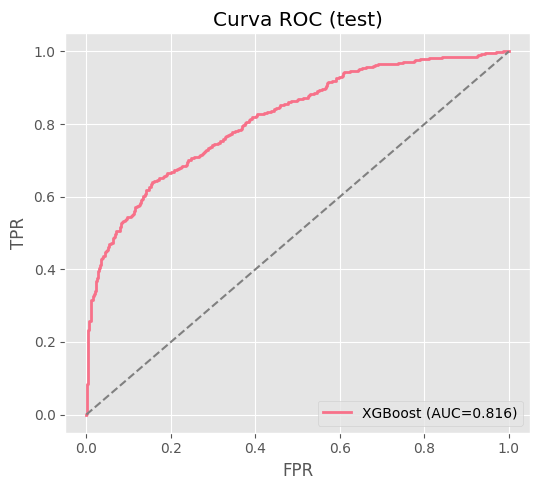

In [14]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, lw=2, label=f'XGBoost (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'--',color='gray')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('Curva ROC (test)')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

In [15]:
# Matriz de confusion (umbral 0.5)
pred = (proba >= 0.5).astype(int)
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred, digits=3))

[[444 152]
 [187 459]]
              precision    recall  f1-score   support

           0      0.704     0.745     0.724       596
           1      0.751     0.711     0.730       646

    accuracy                          0.727      1242
   macro avg      0.727     0.728     0.727      1242
weighted avg      0.728     0.727     0.727      1242



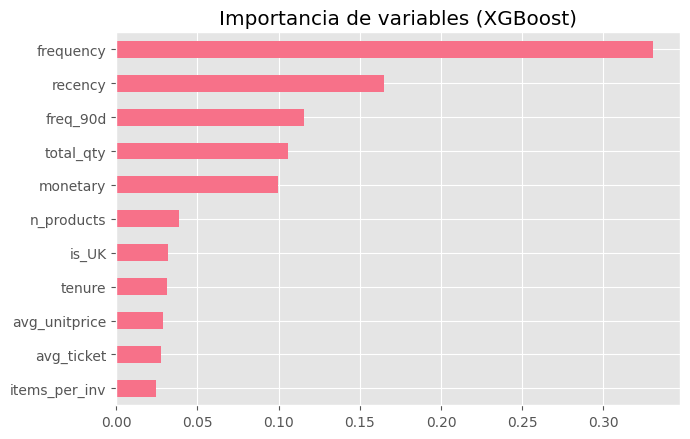

frequency        0.330598
recency          0.164998
freq_90d         0.115642
total_qty        0.105915
monetary         0.099661
n_products       0.038895
is_UK            0.031752
tenure           0.031274
avg_unitprice    0.029087
avg_ticket       0.027651
items_per_inv    0.024527
dtype: float32

In [16]:
# Importancia de variables
imp = pd.Series(best.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(7,4.5))
imp.plot.barh(ax=ax)
ax.set_title('Importancia de variables (XGBoost)')
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False)

## 6. Aplicación de negocio

Convertimos la probabilidad en **segmentos accionables**: ordenamos a los clientes por su score y los dividimos en deciles. Los deciles altos → **fidelización**; los bajos → **retención**.

          clientes  prob_media  tasa_recompra_real
segmento                                          
Muy baja       249       0.168               0.137
Baja           248       0.331               0.371
Media          248       0.492               0.460
Alta           248       0.695               0.690
Muy alta       249       0.917               0.944


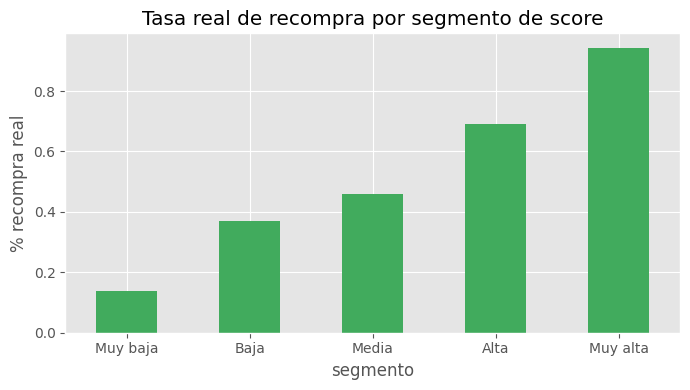

In [17]:
scores = pd.DataFrame({'proba': proba, 'real': y_test.values}, index=X_test.index)
scores['segmento'] = pd.qcut(scores['proba'], 5,
                             labels=['Muy baja','Baja','Media','Alta','Muy alta'])
tabla = scores.groupby('segmento', observed=True).agg(
    clientes=('real','size'),
    prob_media=('proba','mean'),
    tasa_recompra_real=('real','mean'))
print(tabla.round(3))

fig, ax = plt.subplots(figsize=(7,4))
tabla['tasa_recompra_real'].plot.bar(ax=ax, color='#41ab5d')
ax.set_title('Tasa real de recompra por segmento de score')
ax.set_ylabel('% recompra real'); plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

**Lectura de negocio:**
- **Muy alta / Alta probabilidad** → campañas de **fidelización** (cross/up-sell, programa VIP).
- **Muy baja / Baja** → campañas de **retención** (reactivación, descuentos, encuesta de abandono).

**Próximos pasos:** features de estacionalidad y categorías de producto, modelo de *time-to-next-purchase* (supervivencia), CLV, y recalibrar el corte con ventana móvil.